# Objective sweep results

Loads a finished (or in-progress) run of `experiments/run_objective_sweep.py`
(or any `experiments.sweep.run_sweep` call) and inspects it: the headline
sim-vs-bounds table, a plot against a swept axis, and how to drop into one
trial's full detail.

Nothing here re-runs the sweep -- it only reads what is already on disk under
`experiments/results/<run_name>/`. See `experiments/README.md` for what each
column means and for the sweep-side gotchas (the window's two edges,
DW's LB-only default, common random numbers across a sweep, etc.).

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from experiments.objective_sweep import load_results, comparison_table
from experiments.core import DEFAULT_OUT_DIR
from visualization.style import new_figure, style_axes, style_legend, palette

## Point this at a run

`RUN_NAME` is the sub-directory name you passed as `run_name` to `run_sweep`
(or the auto-generated `sweep_<timestamp>` if you didn't pass one -- check
`experiments/results/` on disk, or the last line `run_sweep` printed, if
you're not sure).

In [2]:
RUN_NAME = "1pile_75kwh"  # <-- edit to the run you want to inspect

run_dir = DEFAULT_OUT_DIR / RUN_NAME
df = load_results(RUN_NAME)
print(f"{len(df)} trial(s) loaded from {run_dir / 'results.csv'}")
df.head()

11 trial(s) loaded from D:\OneDrive - University of Toronto\Uni\Ph.D\Thesis\Chapter 2 - Queueing\Python Codes\experiments\results\1pile_75kwh\results.csv


,trial_id,n_piles,n_connectors,n_modules,p_module,queue_capacity,mean_interarrival,max_time,warmup_period,flush_queue_at_warmup,...,dw_mean_sojourn_LB,dw_UB,dw_gap,dw_total_sojourn_UB,dw_mean_sojourn_UB,dw_whole_module_feasible,dw_n_vehicles,dw_n_optimized,dw_K,dw_runtime_s
0,0,1,2,6,25.0,1000,10.000000,120,360,False,...,76.141436,NaN,NaN,NaN,NaN,NaN,25,25,60,62.221100
1,1,1,2,6,25.0,1000,10.909091,120,360,False,...,62.741019,NaN,NaN,NaN,NaN,NaN,22,22,60,68.279585
2,2,1,2,6,25.0,1000,12.000000,120,360,False,...,60.605887,NaN,NaN,NaN,NaN,NaN,17,17,60,65.059266
3,3,1,2,6,25.0,1000,13.333333,120,360,False,...,55.978519,NaN,NaN,NaN,NaN,NaN,13,13,60,36.797745
4,4,1,2,6,25.0,1000,15.000000,120,360,False,...,41.180640,NaN,NaN,NaN,NaN,NaN,13,13,60,51.898971


## Run metadata

`run_meta.json` records the sweep definition and timing: every `TrialConfig`
that was queued (as a dict, via `to_row()`), which of the three stages
(`sim`/`exact`/`dw`) were switched on, and start/finish/total runtime.

In [3]:
meta = json.loads((run_dir / "run_meta.json").read_text())
print("stages run:", meta["stages"])
print("n_trials:  ", meta["n_trials"])
print("started:   ", meta["started"], " finished:", meta.get("finished", "(in progress)"))
if "total_runtime_s" in meta:
    print(f"total runtime: {meta['total_runtime_s']:.1f} s")

stages run: {'sim': True, 'exact': True, 'dw': True}
n_trials:   11
started:    2026-09-21T22:15:40  finished: 2026-09-22T08:58:12
total runtime: 38550.5 s


## Headline view: sim vs. grid vs. exact vs. DW's lower bound

`comparison_table` pulls out the four sources' mean sojourn for one cohort
(default `"all"`) alongside the knobs that identify each row.

**`group` is the important argument.** Every source now reports two
populations:

* `"arrived"` (the default) -- every vehicle the models were given, with
  unfinished ones censored at the horizon. All four columns cover the same
  set, so this is the one to compare on.
* `"completed"` -- only vehicles that received their full energy. Readable,
  but it conditions on an outcome: it drops precisely the longest sojourns,
  and the simulation and the models drop *different* vehicles.

Comparing a `completed` number against an `arrived` one is what makes a
proven optimum look *worse* than feasible FIFO. The `sim_n`/`grid_n`/
`exact_n` columns are shown so any residual mismatch stays visible.

Remember `sim` is continuous-time and NOT the like-for-like target -- compare
against `grid` (that same schedule replayed on the `delta` slot grid);
`dw_LB` is a certified lower bound and `exact` is the MILP's incumbent, so on
every row you should see `grid >= exact >= dw_LB`.

In [4]:
GROUP = "arrived"   # "arrived" (comparable) | "completed" (finished only)

table = comparison_table(df, cohort="all", group=GROUP)
table

,mean_interarrival,max_time,delta,mip_gap,gap_tolerance,sim,grid,exact,dw_LB,sim_n,grid_n,exact_n,exact_status,dw_status,sim_runtime_s,exact_runtime_s,dw_runtime_s
0,10.000000,120,2.0,0.0010,0.000001,81.773347,82.320000,77.680000,76.141436,25.0,25.0,25.0,TIME_LIMIT,CONVERGED,0.043137,7199.295704,62.221100
1,10.909091,120,2.0,0.0010,0.000001,66.282356,67.181818,65.727265,62.741019,22.0,22.0,22.0,TIME_LIMIT,CONVERGED,0.046025,7200.427915,68.279585
2,12.000000,120,2.0,0.0010,0.000001,67.260050,67.882353,62.823529,60.605887,17.0,17.0,17.0,TIME_LIMIT,CONVERGED,0.055485,7200.472458,65.059266
3,13.333333,120,2.0,0.0010,0.000001,63.663306,64.769231,58.153839,55.978519,13.0,13.0,13.0,TIME_LIMIT,CONVERGED,0.059544,5400.222075,36.797745
4,15.000000,120,2.0,0.0010,0.000001,47.140645,48.153846,43.384615,41.180640,13.0,13.0,13.0,TIME_LIMIT,CONVERGED,0.042044,3600.178526,51.898971
5,17.142857,180,2.0,0.0001,0.000001,50.246608,51.428571,51.571428,42.826565,14.0,14.0,14.0,TIME_LIMIT,CONVERGED,0.074322,1800.286673,95.824552
6,20.000000,180,2.0,0.0001,0.000001,36.318412,37.000000,34.666667,32.759078,12.0,12.0,12.0,TIME_LIMIT,CONVERGED,0.029054,1800.187048,40.678283
7,24.000000,240,1.0,0.0001,0.000001,40.111402,40.454545,39.818182,36.547234,11.0,11.0,11.0,TIME_LIMIT,CONVERGED,0.027429,1800.473917,151.527631
8,30.000000,240,1.0,0.0001,0.000001,32.987891,33.500000,31.166667,29.947341,6.0,6.0,6.0,TIME_LIMIT,CONVERGED,0.013648,1800.179699,86.094493
9,40.000000,240,1.0,0.0001,0.000001,18.707298,19.000000,18.833333,18.647640,6.0,6.0,6.0,OPTIMAL,CONVERGED,0.009659,1.452394,10.597634


## All columns

`results.csv` is wide (config knobs + populations + per-source, per-cohort
metrics -- see the README's column-group table). Group by prefix to see
what's available for a given source.

In [5]:
# df[[
#     'mean_interarrival',
#     'exact_objective', 'exact_best_bound', 'exact_mip_gap_achieved', 'exact_runtime_s',
#     'dw_gap_tolerance_used', 'dw_LB', 'dw_z_rmp', 'dw_rmp_gap', 'dw_runtime_s'
# ]]

In [6]:
prefixes = ["inst_", "sim_", "grid_", "exact_", "dw_"]
for p in prefixes:
    cols = [c for c in df.columns if c.startswith(p)]
    print(f"{p:8s} ({len(cols)} columns): {cols}")

inst_    (8 columns): ['inst_n_vehicles', 'inst_n_dropped_late_arrivals', 'inst_n_optimized', 'inst_n_boundary_vehicles', 'inst_n_discarded', 'inst_n_measurement', 'inst_n_queued', 'inst_n_boundary']
sim_     (23 columns): ['sim_clock_end', 'sim_runtime_s', 'sim_completed_measurement_n', 'sim_completed_measurement_total_sojourn', 'sim_completed_measurement_mean_sojourn', 'sim_completed_measurement_queued_n', 'sim_completed_measurement_queued_total_sojourn', 'sim_completed_measurement_queued_mean_sojourn', 'sim_completed_all_n', 'sim_completed_all_total_sojourn', 'sim_completed_all_mean_sojourn', 'sim_arrived_measurement_n', 'sim_arrived_measurement_n_censored', 'sim_arrived_measurement_total_sojourn', 'sim_arrived_measurement_mean_sojourn', 'sim_arrived_measurement_queued_n', 'sim_arrived_measurement_queued_n_censored', 'sim_arrived_measurement_queued_total_sojourn', 'sim_arrived_measurement_queued_mean_sojourn', 'sim_arrived_all_n', 'sim_arrived_all_n_censored', 'sim_arrived_all_total

## Plot: mean sojourn vs. a swept knob

Edit `X_AXIS` (the column to put on the x-axis) and `GROUP_BY` (one line per
distinct value, or `None` to disable) to match whatever you actually swept.
Color encodes the source (sim/grid/exact/dw_LB); line style encodes the
`GROUP_BY` value.

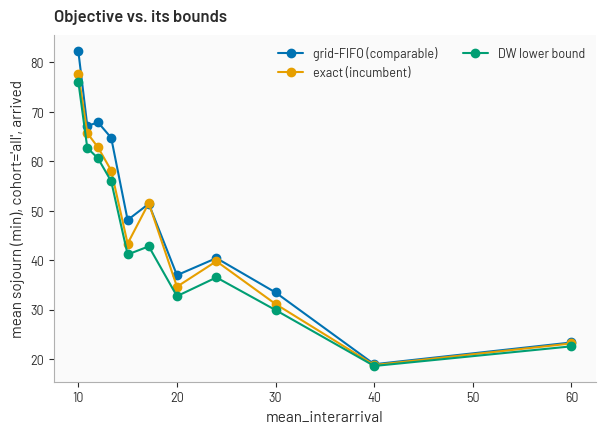

In [7]:
X_AXIS = "mean_interarrival"   # column to put on the x-axis
GROUP_BY = None                # one line per value; set to None to disable
COHORT = "all"                 # "measurement" | "measurement_queued" | "all"
GROUP = "arrived"              # "arrived" (comparable) | "completed"

sources = [
    #(f"sim_{GROUP}_{COHORT}_mean_sojourn", "sim (continuous)"),
    (f"grid_{GROUP}_{COHORT}_mean_sojourn", "grid-FIFO (comparable)"),
    (f"exact_{GROUP}_{COHORT}_mean_sojourn", "exact (incumbent)"),
    ("dw_mean_sojourn_LB", "DW lower bound"),  # DW has no per-cohort LB -- see README
]
sources = [(col, label) for col, label in sources if col in df.columns]
colors = palette(len(sources))
linestyles = ["-", "--", ":", "-."]
groups = sorted(df[GROUP_BY].unique()) if GROUP_BY else [None]

fig, ax = new_figure(figsize=(7, 4.5))
for gi, gval in enumerate(groups):
    sub = df[df[GROUP_BY] == gval].sort_values(X_AXIS) if GROUP_BY else df.sort_values(X_AXIS)
    for (col, label), color in zip(sources, colors):
        line_label = f"{label} ({GROUP_BY}={gval:g})" if GROUP_BY else label
        ax.plot(sub[X_AXIS], sub[col], marker="o", color=color,
                 linestyle=linestyles[gi % len(linestyles)], label=line_label)

ax.set_xlabel(X_AXIS)
ax.set_ylabel(f"mean sojourn (min), cohort='{COHORT}', {GROUP}")
style_axes(ax, title="Objective vs. its bounds")
style_legend(ax, fontsize=7, ncol=2)
plt.show()

,mean_interarrival,max_time,delta,exact_status,dw_status,grid,exact,exact_vs_grid,dw_LB,dw_LB_vs_grid
0,10.00,120,2.0,TIME_LIMIT,CONVERGED,82.32,77.68,5.64,76.14,7.51
1,10.91,120,2.0,TIME_LIMIT,CONVERGED,67.18,65.73,2.17,62.74,6.61
2,12.00,120,2.0,TIME_LIMIT,CONVERGED,67.88,62.82,7.45,60.61,10.72
3,13.33,120,2.0,TIME_LIMIT,CONVERGED,64.77,58.15,10.21,55.98,13.57
4,15.00,120,2.0,TIME_LIMIT,CONVERGED,48.15,43.38,9.90,41.18,14.48
5,17.14,180,2.0,TIME_LIMIT,CONVERGED,51.43,51.57,-0.28,42.83,16.73
6,20.00,180,2.0,TIME_LIMIT,CONVERGED,37.00,34.67,6.31,32.76,11.46
7,24.00,240,1.0,TIME_LIMIT,CONVERGED,40.45,39.82,1.57,36.55,9.66
8,30.00,240,1.0,TIME_LIMIT,CONVERGED,33.50,31.17,6.97,29.95,10.60
9,40.00,240,1.0,OPTIMAL,CONVERGED,19.00,18.83,0.88,18.65,1.85


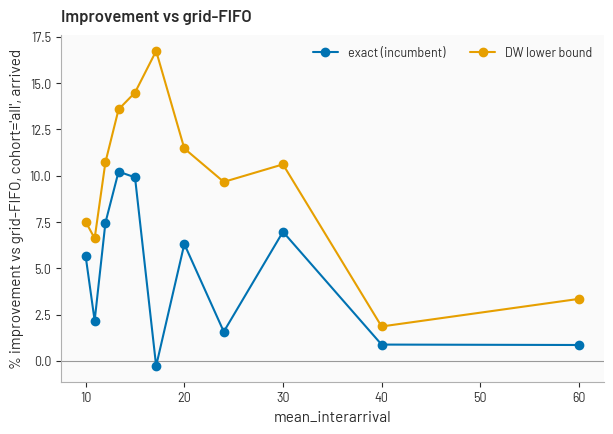

In [8]:
AS_PCT = True  # True: % of grid-FIFO; False: minutes saved (grid - M)

# Improvement vs grid-FIFO (same GROUP / COHORT as the plot cell).
#
# Mean sojourn is minutes per vehicle; lower is better. For a method M
# (exact incumbent, or DW lower bound),
#
#     abs_improvement = grid - M                         # minutes saved
#     pct_improvement = 100 * (grid - M) / grid          # share of grid removed
#
# AS_PCT chooses which of those the table and plot show. Positive means M
# is better than grid-FIFO.
#
# Exact's figure is the improvement of the MILP incumbent (a feasible
# schedule). On a TIME_LIMIT row that understates the true optimum's
# improvement (exact >= z*). DW's figure is the improvement of the
# certified lower bound (dw_LB <= z*), so it is an *upper* bound on how
# much the true optimum can beat grid-FIFO.

grid_col = f"grid_{GROUP}_{COHORT}_mean_sojourn"
exact_col = f"exact_{GROUP}_{COHORT}_mean_sojourn"
dw_col = "dw_mean_sojourn_LB"

id_cols = [c for c in (X_AXIS, "max_time", "delta", "exact_status", "dw_status") if c in df.columns]
imp = df[id_cols].copy()
imp["grid"] = df[grid_col]
if exact_col in df.columns:
    imp["exact"] = df[exact_col]
    abs_exact = imp["grid"] - imp["exact"]
    imp["exact_vs_grid"] = 100.0 * abs_exact / imp["grid"] if AS_PCT else abs_exact
if dw_col in df.columns:
    imp["dw_LB"] = df[dw_col]
    abs_dw = imp["grid"] - imp["dw_LB"]
    imp["dw_LB_vs_grid"] = 100.0 * abs_dw / imp["grid"] if AS_PCT else abs_dw

imp = imp.sort_values(X_AXIS)
display(imp.round(2))

plot_sources = [
    (col, label)
    for col, label in (
        ("exact_vs_grid", "exact (incumbent)"),
        ("dw_LB_vs_grid", "DW lower bound"),
    )
    if col in imp.columns
]
ylabel = (
    f"% improvement vs grid-FIFO, cohort='{COHORT}', {GROUP}"
    if AS_PCT
    else f"minutes saved vs grid-FIFO, cohort='{COHORT}', {GROUP}"
)
colors = palette(len(plot_sources))
fig, ax = new_figure(figsize=(7, 4.5))
for (col, label), color in zip(plot_sources, colors):
    ax.plot(imp[X_AXIS], imp[col], marker="o", color=color, label=label)
ax.axhline(0.0, color="0.6", lw=0.8, zorder=0)
ax.set_xlabel(X_AXIS)
ax.set_ylabel(ylabel)
style_axes(ax, title="Improvement vs grid-FIFO")
style_legend(ax, fontsize=7, ncol=2)
plt.show()

## How much of each row is censored?

The censored share is what decides whether a row is trustworthy. A row where
half the vehicles never finished is dominated by the censoring convention,
not by scheduling quality -- that is the regime where the `completed` and
`arrived` groups disagree most, and where a short `max_time` shows up.

`exact_n_completed_at_horizon` counts vehicles that finished *exactly* at the
horizon edge (`D_j == K` yet fully charged). A nonzero count means the
horizon is binding on the optimum, and is also why completion is tested by
energy rather than by departure slot.

In [11]:
COHORT = "all"
cens = pd.DataFrame({
    "arrived_n": df[f"exact_arrived_{COHORT}_n"],
    "completed_n": df[f"exact_completed_{COHORT}_n"],
    "censored_n": df[f"exact_arrived_{COHORT}_n_censored"],
})
cens["censored_share"] = cens["censored_n"] / cens["arrived_n"]
for col in ("exact_n_completed_at_horizon", "exact_n_at_horizon"):
    if col in df.columns:
        cens[col.replace("exact_", "")] = df[col]
cens.round(3)

,arrived_n,completed_n,censored_n,censored_share,n_completed_at_horizon,n_at_horizon
0,25.0,8.0,17.0,0.680,0,17
1,22.0,8.0,14.0,0.636,0,13
2,17.0,8.0,9.0,0.529,0,9
3,13.0,7.0,6.0,0.462,0,5
4,13.0,7.0,6.0,0.462,0,6
5,14.0,8.0,6.0,0.429,0,5
6,12.0,8.0,4.0,0.333,0,4
7,11.0,8.0,3.0,0.273,0,3
8,6.0,5.0,1.0,0.167,0,1
9,6.0,4.0,2.0,0.333,0,2


## One trial's full detail

`results.csv` is the flattened view; `trials/trial_NNN.json` keeps the same
trial nested (and is where you'd look for anything `flatten_trial` didn't
pull into a column). That file also stores `arrivals`: the EV specs the DES
was fed, which is enough to rebuild the episode (`replay_episode` in the
next section). It does **not** store the env object, and it does **not**
include the per-vehicle schedule table (`ConnectorLaneSolution.per_vehicle` /
`DWSolution.per_vehicle`) -- only the aggregate/by-cohort figures
`run_exact`/`run_dw` returned.

In [13]:
TRIAL_ID = 0  # <-- edit to inspect a different row

trial = json.loads((run_dir / "trials" / f"trial_{TRIAL_ID:03d}.json").read_text())
print("config:", {k: v for k, v in trial["config"].items() if k in
      ("mean_interarrival", "max_time", "delta", "mip_gap", "gap_tolerance",
       "gap_tolerance_target_min", "boundary_mode", "objective_cohorts")})
print()
print("counts:  ", trial["counts"])
print("instance:", trial["instance"])
print()
print("exact:", trial["exact"])
print()
print("dw:   ", trial["dw"])

config: {'mean_interarrival': 10.0, 'max_time': 120, 'delta': 2.0, 'boundary_mode': 'optimize', 'objective_cohorts': 'boundary+measurement+queued', 'mip_gap': 0.001, 'gap_tolerance': 1e-06, 'gap_tolerance_target_min': 0.1}

counts:   {'n_arrived_post_warmup': 11, 'n_queued_at_warmup_end': 12, 'n_in_service_at_warmup_end': 2, 'n_arrived_total': 41, 'n_finished_total': 22, 'n_dropped_total': 0, 'n_flushed_at_warmup': 0, 'sim_clock_end': 480.0, 'sim_runtime_s': 0.043136500054970384}
instance: {'n_vehicles': 25, 'n_dropped_late_arrivals': 0, 'late_arrival_ids': [], 'n_optimized': 25, 'n_boundary_vehicles': 2, 'n_discarded': 0, 'cohort_sizes': {'measurement': 11, 'queued': 12, 'boundary': 2}}

exact: {'status': 'TIME_LIMIT', 'objective': 1261.0, 'best_bound': 894.534676788664, 'mip_gap_achieved': 0.29061484790748293, 'total_sojourn': 1942.0, 'mean_sojourn': 77.68, 'n_vehicles': 25, 'n_optimized': 25, 'K': 60, 'gurobi_runtime_s': 7200.0940001010895, 'build_runtime_s': 0.727967599988915, 'sol

## Rebuild each trial and print utilization

`trials/trial_NNN.json` stores the arrival specs, not the env. This cell
rebuilds every trial (FIFO, proportional power -- the same rollout the sweep
ran) and prints connector utilization.

* `rho_sim` -- fraction of connector-time that was occupied.
* `rho_theory` -- `lambda_eff / (c * mu)`, with `lambda_eff = n_finished / T`
  and `mu = 1 / E[service]`.
* **full** is the whole clock, warm-up included. **measured** is
  `[warmup_period, T]`, the window the sojourn columns use.

A trial written before arrivals were saved is skipped. Re-run
`experiments.run_objective_sweep` to record them.

In [12]:
from experiments.objective_sweep import episode_utilization, replay_episode

rows = []
for trial_id in range(len(df)):
    path = run_dir / "trials" / f"trial_{trial_id:03d}.json"
    trial = json.loads(path.read_text())
    arrivals = trial.get("arrivals") or []
    cfg = trial["config"]
    tag = cfg.get("label") or ""
    if not arrivals:
        print(
            f"trial {trial_id} {tag}: no arrivals saved "
            "(re-run the sweep to record them)"
        )
        continue

    env = replay_episode(cfg, arrivals)
    full = episode_utilization(env, post_warmup=False)
    measured = episode_utilization(env, post_warmup=True)
    print(
        f"trial {trial_id} {tag}  interarrival={cfg['mean_interarrival']:g}  "
        f"full  rho_sim={full['rho_sim']:.3f}  rho_theory={full['rho_theory']:.3f}  "
        f"measured  rho_sim={measured['rho_sim']:.3f}  "
        f"rho_theory={measured['rho_theory']:.3f}"
    )
    rows.append(
        {
            "trial_id": trial_id,
            "label": tag,
            "mean_interarrival": cfg["mean_interarrival"],
            "max_time": cfg["max_time"],
            "rho_sim_full": full["rho_sim"],
            "rho_theory_full": full["rho_theory"],
            "rho_sim_measured": measured["rho_sim"],
            "rho_theory_measured": measured["rho_theory"],
            "n_finished_measured": measured["n_finished"],
        }
    )

pd.DataFrame(rows).round(3) if rows else print("nothing to replay")

trial 0 6veh  interarrival=10  full  rho_sim=0.896  rho_theory=0.832  measured  rho_sim=0.918  rho_theory=0.000
trial 1 5.5veh  interarrival=10.9091  full  rho_sim=0.887  rho_theory=0.833  measured  rho_sim=0.890  rho_theory=0.000
trial 2 5veh  interarrival=12  full  rho_sim=0.875  rho_theory=0.811  measured  rho_sim=0.865  rho_theory=0.000
trial 3 4.5veh  interarrival=13.3333  full  rho_sim=0.863  rho_theory=0.848  measured  rho_sim=0.892  rho_theory=0.092
trial 4 4veh  interarrival=15  full  rho_sim=0.813  rho_theory=0.764  measured  rho_sim=0.890  rho_theory=0.099
trial 5 3.5veh  interarrival=17.1429  full  rho_sim=0.695  rho_theory=0.642  measured  rho_sim=0.944  rho_theory=0.786
trial 6 3veh  interarrival=20  full  rho_sim=0.616  rho_theory=0.563  measured  rho_sim=0.683  rho_theory=0.516
trial 7 2.5veh  interarrival=24  full  rho_sim=0.503  rho_theory=0.447  measured  rho_sim=0.549  rho_theory=0.395
trial 8 2veh  interarrival=30  full  rho_sim=0.372  rho_theory=0.365  measured  r

,trial_id,label,mean_interarrival,max_time,rho_sim_full,rho_theory_full,rho_sim_measured,rho_theory_measured,n_finished_measured
0,0,6veh,10.000,120,0.896,0.832,0.918,0.000,0.0
1,1,5.5veh,10.909,120,0.888,0.833,0.890,0.000,0.0
2,2,5veh,12.000,120,0.875,0.811,0.865,0.000,0.0
3,3,4.5veh,13.333,120,0.862,0.848,0.892,0.092,1.0
4,4,4veh,15.000,120,0.813,0.764,0.890,0.099,1.0
5,5,3.5veh,17.143,180,0.695,0.642,0.944,0.786,8.0
6,6,3veh,20.000,180,0.616,0.563,0.683,0.516,5.0
7,7,2.5veh,24.000,240,0.503,0.447,0.549,0.395,6.0
8,8,2veh,30.000,240,0.372,0.365,0.368,0.349,5.0
9,9,1.5veh,40.000,240,0.240,0.220,0.182,0.184,4.0


## Notes / gotchas (see `experiments/README.md` for the full version)

- **`sim` is not the target.** The offline models can only depart on `delta`
  slot boundaries; compare against `grid`, not `sim`.
- **DW has no per-cohort lower bound.** `dw_mean_sojourn_LB` certifies
  whichever `objective_cohorts` that trial was solved over as a whole -- it
  is not a separate bound for `measurement` vs. `all`. If you need a bound
  for one cohort specifically, that cohort must be `objective_cohorts` for
  its own trial.
- **Watch the `n` columns** (`sim_{cohort}_n`, `grid_{cohort}_n`,
  `exact_{cohort}_n`, `dw_n_optimized`) when comparing `sim`/`grid` against
  `exact`/`dw`: the simulation only counts vehicles that *finished* inside
  the run, the offline models count every vehicle they were given. Different
  `n` means different populations -- the mean-sojourn gap is not
  apples-to-apples until `max_time` is long enough that these line up.
- **Every trial sharing a `seed` sees the same EV population**, on every
  swept axis -- `generate_arrivals` draws inter-arrival gaps and vehicle
  characteristics from separate streams, so vehicle *k*'s battery/SoC
  depend only on *k*. A sweep varies the arrival process alone rather
  than resampling the fleet underneath it. (This replaces the old
  `arrival_horizon` knob, now removed.) Holding `delta_arr` fixed keeps
  the alignment exact -- see the README, "Common random numbers across a
  sweep".